# Video Segmentation with Multiple Bounding Boxes in SAM3

This notebook demonstrates how to use bounding boxes for video segmentation in SAM3/SAM3.1.

**Main Use Case**: Track multiple objects (2+) with their own bounding boxes and propagate across the entire video.

## Setup

In [1]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
import glob
import os
from unittest.mock import patch
from transformers import AutoProcessor, AutoModelForCausalLM
from transformers.dynamic_module_utils import get_imports

device = torch.device("cuda")
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

def plot_bbox(image, data):
    fig, ax = plt.subplots()

    # Display the image
    ax.imshow(image)

    # Plot each bounding box
    for bbox, label in zip(data['bboxes'], data['labels']):
        # Unpack the bounding box coordinates
        x1, y1, x2, y2 = bbox
        # Create a Rectangle patch
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='r', facecolor='none')
        # Add the rectangle to the Axes
        ax.add_patch(rect)
        # Annotate the label
        plt.text(x1, y1, label, color='white', fontsize=8, bbox=dict(facecolor='red', alpha=0.5))

    # Remove the axis ticks and labels
    ax.axis('off')

    # Show the plot
    plt.show()

/cluster/scratch/niacobone/sam3/myenv/lib/python3.12/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
import sam3

from sam3.model_builder import build_sam3_video_model
from sam3.visualization_utils import show_box, show_mask


# Build SAM3 model
sam3_model = build_sam3_video_model()
predictor = sam3_model.tracker
predictor.backbone = sam3_model.detector.backbone

# Get path to video
sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")
video_path = f"{sam3_root}/assets/videos/bedroom.mp4"

print(f"Loading video from: {video_path}")

/cluster/scratch/niacobone/sam3/myenv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO 2026-05-26 18:10:52,284 2280379 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16


Loading video from: /cluster/scratch/niacobone/sam3/sam3/../assets/videos/bedroom.mp4


In [3]:
# Load video frames for visualization
cap = cv2.VideoCapture(video_path)
video_frames_for_vis = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    video_frames_for_vis.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
cap.release()

frame0 = video_frames_for_vis[0]
width, height = frame0.shape[1], frame0.shape[0]
print(f"Video resolution: {width}x{height}, Total frames: {len(video_frames_for_vis)}")

Video resolution: 960x540, Total frames: 200


## Track 2 Objects with Bounding Boxes and Propagate Through Video

This is the primary way to use multiple bounding boxes in SAM3 - provide one box per object and track them across the entire video.

In [4]:
# Initialize inference state
inference_state = predictor.init_state(video_path=video_path)

# Clear any previous prompts
predictor.clear_all_points_in_video(inference_state)

print("Inference state initialized and ready for prompts.")

Inference state initialized and ready for prompts.


In [5]:
image = Image.fromarray(frame0)

def fixed_get_imports(filename: str | os.PathLike) -> list[str]:
    if not str(filename).endswith("modeling_florence2.py"):
        return get_imports(filename)
    imports = get_imports(filename)
    imports.remove("flash_attn")
    return imports

def run_example(task_prompt, text_input=None):
    if text_input is None:
        prompt = task_prompt
    else:
        prompt = task_prompt + text_input
    inputs = processor(text=prompt, images=image, return_tensors="pt").to('cuda', torch.float16)
    generated_ids = model.generate(
      input_ids=inputs["input_ids"].cuda(),
      pixel_values=inputs["pixel_values"].cuda(),
      max_new_tokens=1024,
      early_stopping=False,
      do_sample=False,
      num_beams=3,
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    parsed_answer = processor.post_process_generation(
        generated_text, 
        task=task_prompt, 
        image_size=(image.width, image.height)
    )

    return parsed_answer

with patch("transformers.dynamic_module_utils.get_imports", fixed_get_imports):
    model = AutoModelForCausalLM.from_pretrained(
        "microsoft/Florence-2-large",
        torch_dtype=torch_dtype,
        trust_remote_code=True,
        attn_implementation="sdpa"
    ).to(device)

processor = AutoProcessor.from_pretrained(
    "microsoft/Florence-2-large",
    trust_remote_code=True
)

task_prompt = '<OD>'
results = run_example(task_prompt)
print(results)

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- configuration_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- modeling_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- configuration_florence2.py
. Make sur

{'<OD>': {'bboxes': [[1.4399999380111694, 285.9300231933594, 728.1599731445312, 539.1900024414062], [142.55999755859375, 133.65000915527344, 299.0400085449219, 406.8900146484375], [306.7200012207031, 0.27000001072883606, 518.8800048828125, 399.33001708984375], [0.47999998927116394, 0.27000001072883606, 959.5199584960938, 539.1900024414062], [378.7200012207031, 34.83000183105469, 436.3199768066406, 100.71000671386719], [521.760009765625, 287.5500183105469, 685.9199829101562, 417.69000244140625], [429.5999755859375, 317.25, 542.8800048828125, 403.6500244140625]], 'labels': ['bed', 'boy', 'girl', 'house', 'human face', 'pillow', 'pillow']}}


In [6]:
print(results['<OD>']['bboxes'])

[[1.4399999380111694, 285.9300231933594, 728.1599731445312, 539.1900024414062], [142.55999755859375, 133.65000915527344, 299.0400085449219, 406.8900146484375], [306.7200012207031, 0.27000001072883606, 518.8800048828125, 399.33001708984375], [0.47999998927116394, 0.27000001072883606, 959.5199584960938, 539.1900024414062], [378.7200012207031, 34.83000183105469, 436.3199768066406, 100.71000671386719], [521.760009765625, 287.5500183105469, 685.9199829101562, 417.69000244140625], [429.5999755859375, 317.25, 542.8800048828125, 403.6500244140625]]


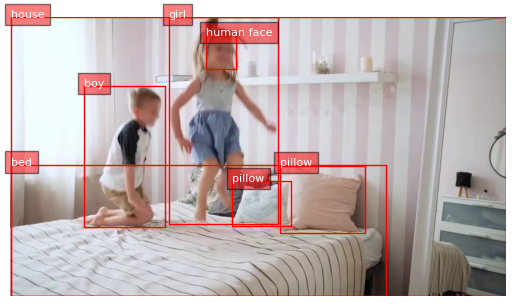

In [7]:
plot_bbox(image, results['<OD>'])

In [8]:
# Step 1: Use all automatically detected bounding boxes from frame 0
ann_frame_idx = 0

det_boxes = np.array(results["<OD>"]["bboxes"], dtype=np.float32)

if len(det_boxes) < 1:
    raise ValueError("No detected boxes found.")

obj_ids = list(range(1, len(det_boxes) + 1))
rel_boxes = [
    np.array([[b[0] / width, b[1] / height, b[2] / width, b[3] / height]], dtype=np.float32)
    for b in det_boxes
]

for obj_id, box in zip(obj_ids, det_boxes):
    print(f"Object {obj_id}: Box in pixels: {box}")


Object 1: Box in pixels: [  1.4399999 285.93002   728.16      539.19     ]
Object 2: Box in pixels: [142.56    133.65001 299.04    406.89   ]
Object 3: Box in pixels: [3.0672000e+02 2.7000001e-01 5.1888000e+02 3.9933002e+02]
Object 4: Box in pixels: [4.7999999e-01 2.7000001e-01 9.5951996e+02 5.3919000e+02]
Object 5: Box in pixels: [378.72     34.83    436.31998 100.71001]
Object 6: Box in pixels: [521.76    287.55002 685.92    417.69   ]
Object 7: Box in pixels: [429.59998 317.25    542.88    403.65002]


In [ ]:
# Step 2: Add prompts for all detected objects on frame 0
print(f"Adding prompts for {len(obj_ids)} objects on frame {ann_frame_idx}...")

out_obj_ids = []
video_res_masks_list = []

# Add each detected object's box
for obj_id, rel_box, box in zip(obj_ids, rel_boxes, det_boxes):
    _, out_ids, _, video_res_masks = predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=ann_frame_idx,
        obj_id=obj_id,
        box=rel_box,
    )
    # collect returned object ids and the corresponding masks
    for j, out_id in enumerate(out_ids):
        out_obj_ids.append(out_id)
        video_res_masks_list.append(video_res_masks[j])

print(f"Added prompts. Tracked objects: {out_obj_ids}")

Adding prompts for 7 objects on frame 0...
Added prompts. Tracked objects: [1, 1, 2, 1, 2, 3, 1, 2, 3, 4, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 6, 7]


IndexError: list index out of range

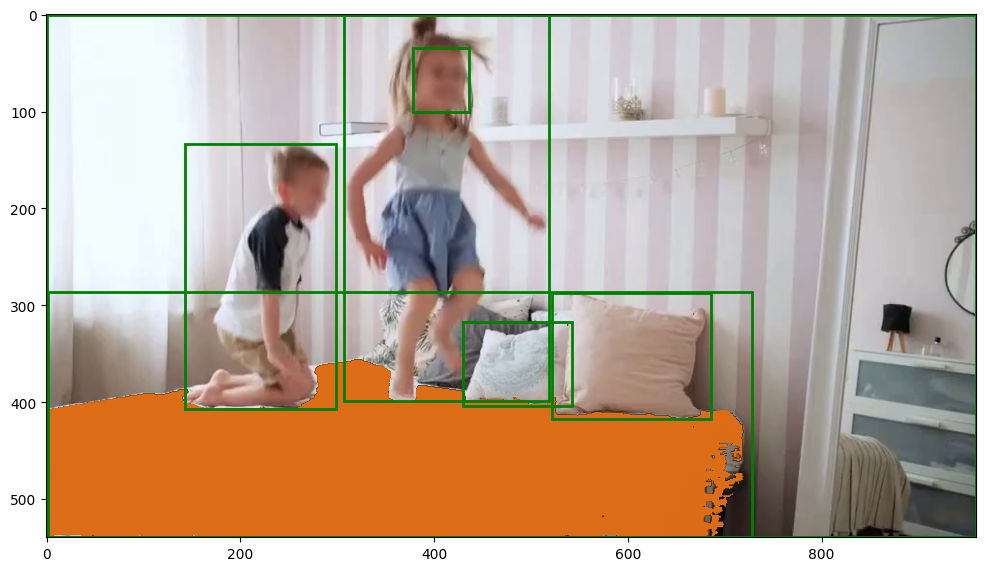

In [10]:
# Step 3: Visualize the prompts and initial segmentations on frame 0
plt.figure(figsize=(12, 8))
plt.imshow(video_frames_for_vis[ann_frame_idx])

# Draw boxes for all detected objects
for box in det_boxes:
    show_box(box, plt.gca())

# Draw segmentation masks for all objects
for i, obj_id in enumerate(out_obj_ids):
    mask = (video_res_masks_list[i] > 0.0).cpu().numpy()
    show_mask(mask, plt.gca(), obj_id=obj_id)

plt.title(f"Frame {ann_frame_idx}: Initial Segmentation with {len(out_obj_ids)} Bounding Box Prompts")
plt.axis('off')
plt.tight_layout()
plt.show()

for obj_id in out_obj_ids:
    print(f"Object {obj_id}: segmentation mask")

In [ ]:
# Step 4: Propagate prompts through the entire video
print("\nPropagating prompts through the entire video...")
print("This tracks both objects across all frames.\n")

video_segments = {}  # Store results for all frames

for frame_idx, obj_ids, low_res_masks, video_res_masks, obj_scores in predictor.propagate_in_video(
    inference_state, 
    start_frame_idx=ann_frame_idx,
    max_frame_num_to_track=len(video_frames_for_vis),  # Track all frames
    reverse=False,
    propagate_preflight=True
):
    video_segments[frame_idx] = {
        out_obj_id: (video_res_masks[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(obj_ids)
    }

print(f"✓ Propagation complete. Segmented {len(video_segments)} frames with {len(out_obj_ids)} objects.")


Propagating prompts through the entire video...
This tracks both objects across all frames.



propagate in video:   0%|          | 0/200 [00:00<?, ?it/s]

✓ Propagation complete. Segmented 200 frames with 2 objects.


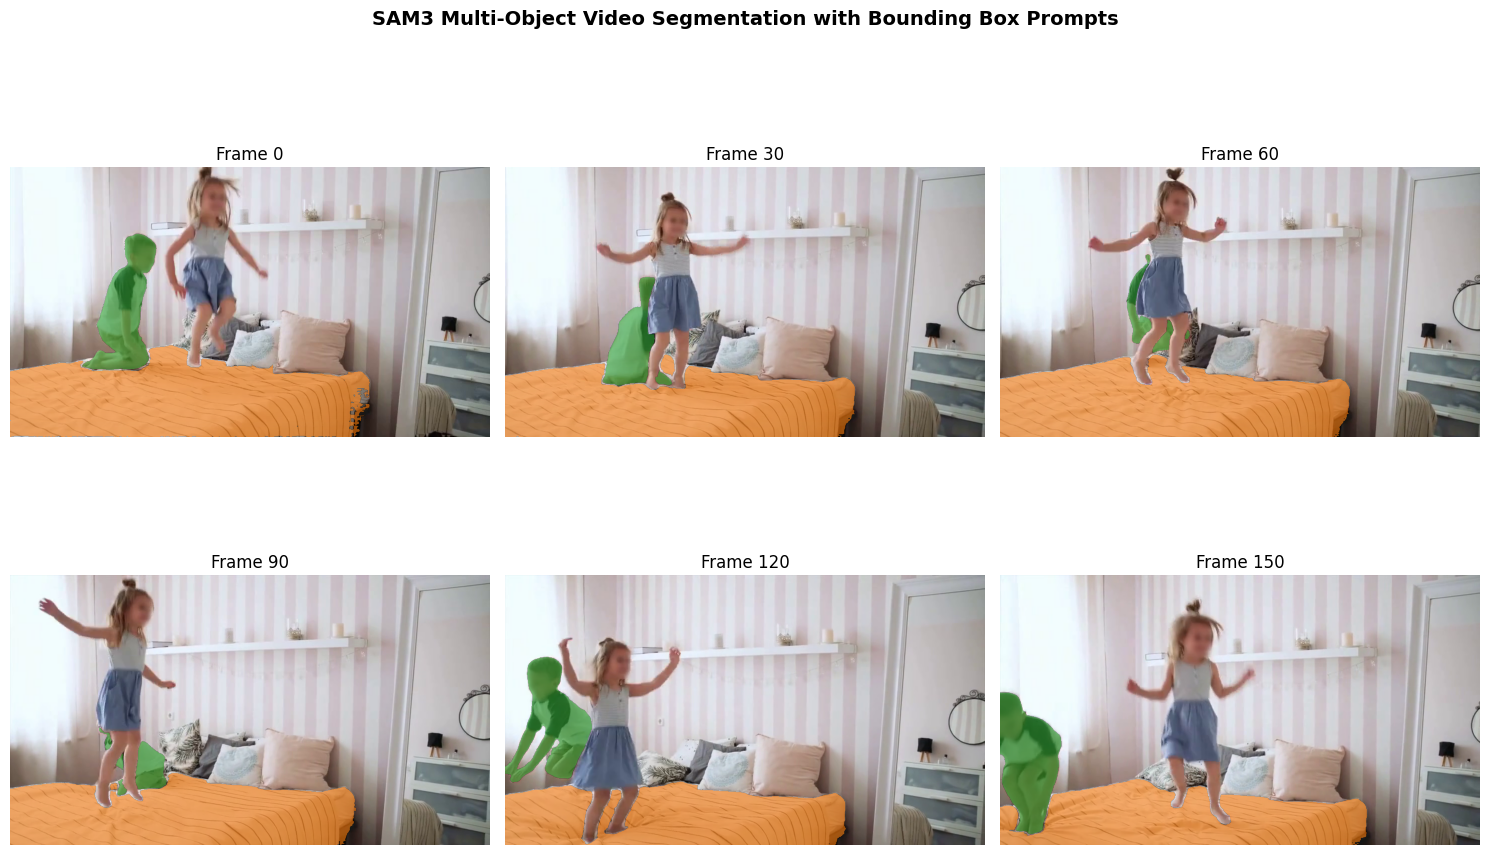


Showing frames: [0, 30, 60, 90, 120, 150]
Stride: 30 frames


In [ ]:
# Step 5: Visualize tracking results every N frames
vis_frame_stride = 30
frame_indices = list(range(0, len(video_frames_for_vis), vis_frame_stride))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for plot_idx, frame_idx in enumerate(frame_indices):
    ax = axes[plot_idx]
    ax.imshow(video_frames_for_vis[frame_idx])
    
    # Draw segmentation masks for this frame
    if frame_idx in video_segments:
        for out_obj_id, out_mask in video_segments[frame_idx].items():
            show_mask(out_mask, ax, obj_id=out_obj_id)
    
    ax.set_title(f"Frame {frame_idx}")
    ax.axis('off')

plt.suptitle("SAM3 Multi-Object Video Segmentation with Bounding Box Prompts", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nShowing frames: {frame_indices}")
print(f"Stride: {vis_frame_stride} frames")

In [ ]:
# Step 6: Summary statistics
print("\n" + "="*60)
print("TRACKING SUMMARY")
print("="*60)

for obj_id in out_obj_ids:
    frames_with_object = sum(1 for frame_idx in video_segments if obj_id in video_segments[frame_idx])
    print(f"Object {obj_id}:")
    print(f"  - Tracked in {frames_with_object}/{len(video_segments)} frames")
    
    # Calculate mask sizes
    mask_sizes = []
    for frame_idx in video_segments:
        if obj_id in video_segments[frame_idx]:
            mask = video_segments[frame_idx][obj_id]
            mask_sizes.append(np.sum(mask))
    
    if mask_sizes:
        avg_size = np.mean(mask_sizes)
        print(f"  - Average mask size: {avg_size:.0f} pixels")

print("\nTracking completed successfully!")
print("="*60)

## API Reference: Using Multiple Bounding Boxes

### Key Function: `add_new_points_or_box()`

```python
predictor.add_new_points_or_box(
    inference_state=inference_state,  # State from init_state()
    frame_idx=0,                      # Frame to add prompt on
    obj_id=1,                         # Unique ID for this object
    box=rel_box,                      # Box as [x_min, y_min, x_max, y_max] in [0,1]
)
```

### Workflow: 3 Steps

1. **Initialize State**
   ```python
   inference_state = predictor.init_state(video_path=video_path)
   ```

2. **Add Box Prompts for Each Object**
   ```python
   # Object 1
   predictor.add_new_points_or_box(
       inference_state=inference_state,
       frame_idx=0,
       obj_id=1,
       box=rel_box_1,
   )
   
   # Object 2
   predictor.add_new_points_or_box(
       inference_state=inference_state,
       frame_idx=0,
       obj_id=2,
       box=rel_box_2,
   )
   ```

3. **Propagate Through Video**
   ```python
   for frame_idx, obj_ids, _, video_res_masks, _ in predictor.propagate_in_video(
       inference_state,
       start_frame_idx=0,
       max_frame_num_to_track=len(video_frames),
       reverse=False,
   ):
       # Process results for each frame
       pass
   ```

### Important Notes

- **One box per object**: Each object gets exactly one bounding box (cannot pass multiple boxes for single object)
- **Unique IDs**: Each object must have a unique `obj_id` (any integer)
- **Normalized coordinates**: Box must be in range [0, 1]
  - Convert from pixels: `rel_box = [x_min/width, y_min/height, x_max/width, y_max/height]`
- **Call order**: Add prompts for all objects before calling `propagate_in_video()`
- **Propagation direction**: 
  - `reverse=False` for forward tracking
  - `reverse=True` for backward tracking

## Optional: Comparing Multiple Box Proposals for One Object

In [ ]:
# Use different obj_ids to compare multiple box proposals
inference_state = predictor.init_state(video_path=video_path)
predictor.clear_all_points_in_video(inference_state)

ann_frame_idx = 0

# Multiple proposals for the same object (e.g., from different detectors)
box_proposals = [
    {"proposal_id": 1, "box": [290, 20, 510, 420], "label": "Loose"},
    {"proposal_id": 2, "box": [310, 50, 480, 380], "label": "Tight"},
    {"proposal_id": 3, "box": [300, 0, 500, 400], "label": "Medium"},
]

proposal_masks = {}

for proposal in box_proposals:
    proposal_id = proposal["proposal_id"]
    box = np.array([proposal["box"]], dtype=np.float32)
    rel_box = np.array([[box[0, 0] / width, box[0, 1] / height, 
                         box[0, 2] / width, box[0, 3] / height]], dtype=np.float32)
    
    _, out_obj_ids, _, video_res_masks = predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=ann_frame_idx,
        obj_id=100 + proposal_id,
        box=rel_box,
    )
    
    proposal_masks[proposal_id] = {
        "mask": (video_res_masks[0] > 0.0).cpu().numpy(),
        "label": proposal["label"],
        "box": box[0],
    }

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, (proposal_id, data) in enumerate(proposal_masks.items()):
    ax = axes[idx]
    ax.imshow(video_frames_for_vis[ann_frame_idx])
    show_box(data["box"], ax)
    show_mask(data["mask"], ax, obj_id=100 + proposal_id)
    ax.set_title(f"Proposal {proposal_id}: {data['label']}")
    ax.axis('off')

plt.suptitle("Comparing Box Proposals (Select Best for Propagation)", fontsize=14)
plt.tight_layout()
plt.show()